In [1]:
import sys
import os
sys.path.append('/project/GCRB/Hon_lab/s223695/Data_project/Perturb_seq_shared/')

import pandas as pd
import numpy as np
import scanpy as sc

from sklearn.cluster import KMeans
import scipy.stats
from itertools import combinations
from sklearn.metrics import pairwise_distances

import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.labelsize' : 'large'}) 
from matplotlib.backends.backend_pdf import PdfPages

from tqdm import tqdm
from tqdm.contrib.concurrent import process_map

import gc
import warnings
import time
import pickle
import json

from sklearn.metrics import pairwise_distances
from multiprocessing import Pool
import torch

from importlib import reload
import util_functions

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
ad_te_merge = sc.read_h5ad("/project/GCRB/Hon_lab/s223695/Data_project/20241108_TFperturb_TE_analysis/concat_df_final_chikara_scaled.h5ad")

In [16]:
ad_te_merge

AnnData object with n_obs × n_vars = 735434 × 50823
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'genic_counts', 'repetitive_counts', 'pct_repetitive', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'type', 'class', 'group', 'n_counts', 'mean', 'std'
    uns: 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'X_umap_original'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


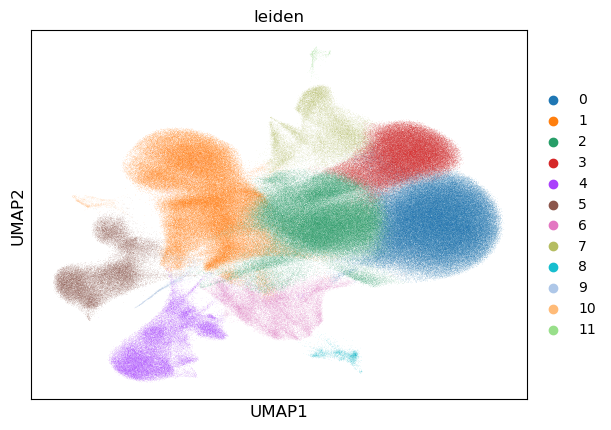

In [17]:
sc.pl.umap(ad_te_merge,color=["leiden"])

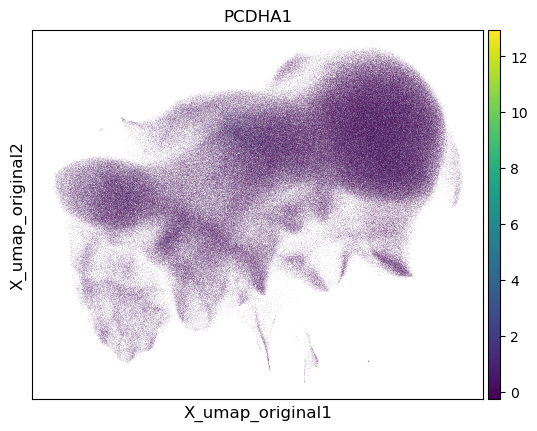

In [18]:
sc.pl.embedding(ad_te_merge,'X_umap_original',color=["PCDHA1"])

In [68]:
plot_list = ["TNNT2","FN1","LTR19C","LTR32"]
vamx_list = [2.8,5,1,1]

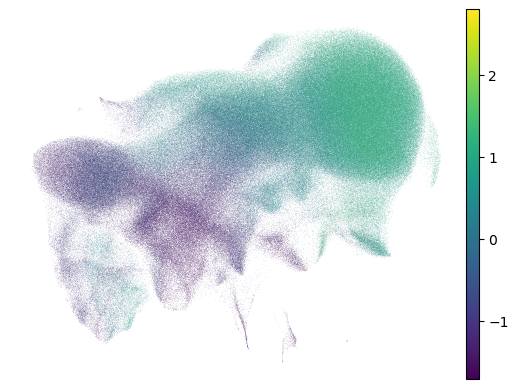

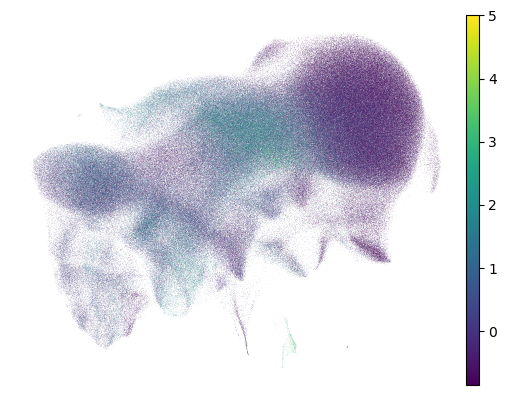

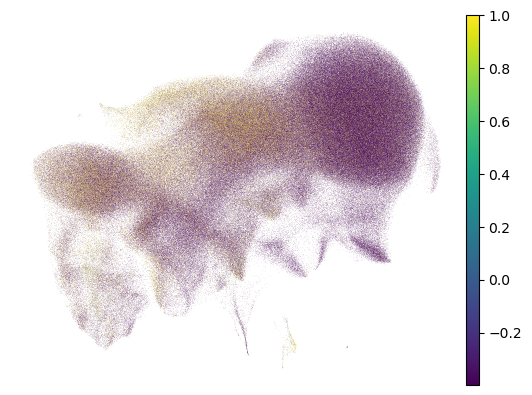

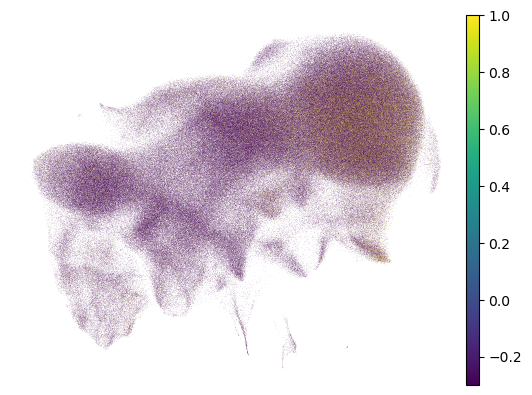

In [70]:
for i,gene_name in enumerate(plot_list):
    fig,ax = plt.subplots()
    sc.pl.embedding(ad_te_merge,'X_umap_original',
                    color=gene_name,vmax=vamx_list[i],ax=ax,show=False)
    ax.spines["top"].set_linewidth(0)
    ax.spines["left"].set_linewidth(0)
    ax.spines["bottom"].set_linewidth(0)
    ax.spines["right"].set_linewidth(0)
    
    ax.set_title("")
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.savefig("./figure/umap_"+gene_name+".png")